In [1]:
  !pip install -q pypdf langchain langchain-community langchain-text-splitters sentence-transformers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 395.5/395.5 kB 12.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 73.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 63.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.4/69.4 kB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 8.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.34.2 which is incompatible.


In [2]:
# !pip install chromadb==0.5.5

In [3]:
import os

for file in os.listdir('/content'):
    print(file)

.config
dive_into_deep_learning.pdf
UnderstandingDeepLearning_02_09_26_C.pdf
book.pdf
sample_data


In [4]:
DATA_DIR = "/content"

pdf_files = [f for f in os.listdir(DATA_DIR) if f.endswith(".pdf")]

print("Number of PDFs:", len(pdf_files))

for pdf in pdf_files:
    print(pdf)

Number of PDFs: 3
dive_into_deep_learning.pdf
UnderstandingDeepLearning_02_09_26_C.pdf
book.pdf


In [5]:
from pathlib import Path
from pypdf import PdfReader

DATA_DIR = Path("/content")

documents = []

for pdf_file in DATA_DIR.glob("*.pdf"):
    reader = PdfReader(str(pdf_file))

    for page_number, page in enumerate(reader.pages, start=1):
        text = page.extract_text() or ""

        documents.append({
            "source": pdf_file.name,
            "page": page_number,
            "text": text
        })

print("Total pages:", len(documents))

Total pages: 1916


In [6]:
for doc in documents[:5]:
    print("Source:", doc["source"])
    print("Page:", doc["page"])
    print("Characters:", len(doc["text"]))
    print("Preview:", doc["text"][:300])
    print("-" * 60)

Source: dive_into_deep_learning.pdf
Page: 1
Characters: 85
Preview: Dive into Deep Learning
ASTON ZHANG, ZACHARY C. LIPTON, MU LI, AND ALEXANDER J.
SMOLA
------------------------------------------------------------
Source: dive_into_deep_learning.pdf
Page: 2
Characters: 0
Preview: 
------------------------------------------------------------
Source: dive_into_deep_learning.pdf
Page: 3
Characters: 751
Preview: Contents
Preface page xxv
Installation xxxiv
Notation xxxvii
1 Introduction 1
1.1 A Motivating Example 2
1.2 Key Components 4
1.3 Kinds of Machine Learning Problems 7
1.4 Roots 20
1.5 The Road to Deep Learning 22
1.6 Success Stories 25
1.7 The Essence of Deep Learning 27
1.8 Summary 29
1.9 Exercises
------------------------------------------------------------
Source: dive_into_deep_learning.pdf
Page: 4
Characters: 1273
Preview: 2.3.2 Vectors 42
2.3.3 Matrices 43
2.3.4 Tensors 44
2.3.5 Basic Properties of Tensor Arithmetic 45
2.3.6 Reduction 46
2.3.7 Non-Reduction Sum 47
2.3.8 Dot 

In [7]:
from pathlib import Path
from pypdf import PdfReader

pdf_files = list(Path("/content").glob("*.pdf"))

for pdf_file in pdf_files:
    reader = PdfReader(str(pdf_file))

    total_pages = len(reader.pages)
    non_empty_pages = 0
    empty_pages = 0
    total_characters = 0

    for page in reader.pages:
        text = page.extract_text() or ""
        characters = len(text.strip())

        if characters > 0:
            non_empty_pages += 1
        else:
            empty_pages += 1

        total_characters += characters

    print("=" * 60)
    print("File:", pdf_file.name)
    print("Total pages:", total_pages)
    print("Pages with text:", non_empty_pages)
    print("Empty pages:", empty_pages)
    print("Total characters:", total_characters)

File: dive_into_deep_learning.pdf
Total pages: 1151
Pages with text: 1149
Empty pages: 2
Total characters: 2275809


File: UnderstandingDeepLearning_02_09_26_C.pdf
Total pages: 541
Pages with text: 537
Empty pages: 4
Total characters: 1312518
File: book.pdf
Total pages: 224
Pages with text: 223
Empty pages: 1
Total characters: 576003


In [8]:
from pathlib import Path
from pypdf import PdfReader
from langchain_core.documents import Document
from langchain_text_splitters import RecursiveCharacterTextSplitter

pdf_files = list(Path("/content").glob("*.pdf"))

documents = []

for pdf_file in pdf_files:
    reader = PdfReader(str(pdf_file))

    for page_num, page in enumerate(reader.pages, start=1):
        text = page.extract_text() or ""
        text = text.strip()

        if text:
            documents.append(
                Document(
                    page_content=text,
                    metadata={
                        "source": pdf_file.name,
                        "page": page_num
                    }
                )
            )

print("Page documents:", len(documents))

Page documents: 1909


In [9]:
text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=1000,
    chunk_overlap=200
)

chunks = text_splitter.split_documents(documents)

print("Total chunks:", len(chunks))

Total chunks: 5716


In [10]:
print("First chunk:")
print(chunks[0].page_content[:500])

print("\nMetadata:")
print(chunks[0].metadata)

First chunk:
Dive into Deep Learning
ASTON ZHANG, ZACHARY C. LIPTON, MU LI, AND ALEXANDER J.
SMOLA

Metadata:
{'source': 'dive_into_deep_learning.pdf', 'page': 1}


In [11]:
from sentence_transformers import SentenceTransformer

embedding_model = SentenceTransformer("all-MiniLM-L6-v2")

print("Embedding model loaded successfully!")

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Embedding model loaded successfully!


In [12]:
!pip install chromadb
import chromadb
from chromadb.utils import embedding_functions

chroma_client = chromadb.PersistentClient(
    path="/content/vector_store"
)

embedding_function = embedding_functions.SentenceTransformerEmbeddingFunction(
    model_name="all-MiniLM-L6-v2"
)

collection = chroma_client.get_or_create_collection(
    name="deep_learning_docs",
    embedding_function=embedding_function
)

print("Chroma collection created successfully!")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.3/23.3 MB 85.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.2/278.2 kB 32.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.6/4.6 MB 130.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.6/23.6 MB 22.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.5/72.5 kB 9.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.2/137.2 kB 17.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.0/60.0 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.6/204.6 kB 25.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.7/95.7 kB 12.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.6/60.6 kB 7.8 MB/s eta 0:00:00
  Attempting uninstall: opentelemetry-api
    Found existing installation: opentelemetry-api 1.42.1
    Uninstalling opentelemet

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Chroma collection created successfully!


In [13]:
import chromadb
import numpy as np

print("ChromaDB:", chromadb.__version__)
print("NumPy:", np.__version__)

ChromaDB: 1.5.9
NumPy: 2.1.3


In [14]:
batch_size = 500

for i in range(0, len(chunks), batch_size):
    batch = chunks[i:i + batch_size]

    ids = [
        f"chunk_{j}"
        for j in range(i, i + len(batch))
    ]

    texts = [
        chunk.page_content
        for chunk in batch
    ]

    metadatas = [
        chunk.metadata
        for chunk in batch
    ]

    collection.add(
        ids=ids,
        documents=texts,
        metadatas=metadatas
    )

    print(f"Added {min(i + batch_size, len(chunks))}/{len(chunks)} chunks")

Added 500/5716 chunks
Added 1000/5716 chunks
Added 1500/5716 chunks
Added 2000/5716 chunks
Added 2500/5716 chunks
Added 3000/5716 chunks
Added 3500/5716 chunks
Added 4000/5716 chunks
Added 4500/5716 chunks
Added 5000/5716 chunks
Added 5500/5716 chunks
Added 5716/5716 chunks


In [15]:
print("Number of vectors:", collection.count())

Number of vectors: 5716


In [16]:
results = collection.query(
    query_texts=["What is backpropagation?"],
    n_results=5
)

for i in range(5):
    print("=" * 60)
    print("Source:", results["metadatas"][0][i])
    print(results["documents"][0][i][:500])

Source: {'source': 'book.pdf', 'page': 66}
58
 How the backpropagation algorithm works
2
Source: {'page': 64, 'source': 'book.pdf'}
And even if not, I hope this line of thinking gives you some insight into what backpropagation
is accomplishing.
What about the other mystery – how backpropagation could have been discovered in
the ﬁrst place? In fact, if you follow the approach I just sketched you will discover a proof
of backpropagation. Unfortunately, the proof is quite a bit longer and more complicated
than the one I described earlier in this chapter. So how was that short (but more mysterious)
proof discovered? What you ﬁnd
Source: {'source': 'book.pdf', 'page': 47}
39
22222
How the backpropagation
algorithm works
In the last chapter we saw how neural networks can learn their weights and biases using
the gradient descent algorithm. There was, however, a gap in our explanation: we didn’t
discuss how to compute the gradient of the cost function. That’s quite a gap! In this
chapter I’

In [17]:
def retrieve_documents(question, n_results=5):
    results = collection.query(
        query_texts=[question],
        n_results=n_results
    )

    retrieved_docs = []

    for i in range(len(results["documents"][0])):
        retrieved_docs.append({
            "text": results["documents"][0][i],
            "source": results["metadatas"][0][i]["source"],
            "page": results["metadatas"][0][i]["page"]
        })

    return retrieved_docs

In [18]:
question = "What is backpropagation?"

retrieved = retrieve_documents(question, n_results=5)

for i, doc in enumerate(retrieved, start=1):
    print("=" * 60)
    print(f"Result {i}")
    print(f"Source: {doc['source']}")
    print(f"Page: {doc['page']}")
    print(doc["text"][:400])

Result 1
Source: book.pdf
Page: 66
58
 How the backpropagation algorithm works
2
Result 2
Source: book.pdf
Page: 64
And even if not, I hope this line of thinking gives you some insight into what backpropagation
is accomplishing.
What about the other mystery – how backpropagation could have been discovered in
the ﬁrst place? In fact, if you follow the approach I just sketched you will discover a proof
of backpropagation. Unfortunately, the proof is quite a bit longer and more complicated
than the one I described
Result 3
Source: book.pdf
Page: 47
39
22222
How the backpropagation
algorithm works
In the last chapter we saw how neural networks can learn their weights and biases using
the gradient descent algorithm. There was, however, a gap in our explanation: we didn’t
discuss how to compute the gradient of the cost function. That’s quite a gap! In this
chapter I’ll explain a fast algorithm for computing such gradients, an algorithm known as
Result 4
Source: book.pdf
Page: 47
with each

In [19]:
evaluation_questions = [
    "What is backpropagation?",
    "What is gradient descent?",
    "What is the purpose of activation functions in neural networks?",
    "How does a convolutional neural network work?",
    "What is the difference between CNNs and RNNs?",
    "What is dropout and why is it used?",
    "What is the vanishing gradient problem?",
    "What is self-attention?",
    "What is a Transformer?",
    "What is overfitting in deep learning?"
]

In [20]:
for question in evaluation_questions:
    retrieved = retrieve_documents(question, n_results=3)

    print("=" * 80)
    print("QUESTION:", question)

    for i, doc in enumerate(retrieved, start=1):
        print(f"\nResult {i}")
        print(f"Source: {doc['source']}, Page: {doc['page']}")
        print(doc["text"][:250].replace("\n", " "))

QUESTION: What is backpropagation?

Result 1
Source: book.pdf, Page: 66
58  How the backpropagation algorithm works 2

Result 2
Source: book.pdf, Page: 64
And even if not, I hope this line of thinking gives you some insight into what backpropagation is accomplishing. What about the other mystery – how backpropagation could have been discovered in the ﬁrst place? In fact, if you follow the approach I ju

Result 3
Source: book.pdf, Page: 47
39 22222 How the backpropagation algorithm works In the last chapter we saw how neural networks can learn their weights and biases using the gradient descent algorithm. There was, however, a gap in our explanation: we didn’t discuss how to compute th
QUESTION: What is gradient descent?

Result 1
Source: dive_into_deep_learning.pdf, Page: 126
86 Linear Neural Networks for Regression Minibatch Stochastic Gradient Descent Fortunately, even in cases where we cannot solve the models analytically, we can still of- ten train models effectively in practice

In [21]:
def build_prompt(question, retrieved_docs):
    context_parts = []

    for i, doc in enumerate(retrieved_docs, start=1):
        context_parts.append(
            f"[Source {i}: {doc['source']}, Page {doc['page']}]\n"
            f"{doc['text']}"
        )

    context = "\n\n".join(context_parts)

    prompt = f"""
You are a Deep Learning Assistant.

Answer the user's question using ONLY the provided context.

Rules:
- Do not use information that is not supported by the context.
- If the context does not contain enough information to answer the question,
  say that the information is not available in the provided documents.
- Give a clear and concise answer.
- Mention the relevant source and page numbers at the end of the answer.

Context:
{context}

Question:
{question}

Answer:
"""

    return prompt

In [22]:
question = "What is backpropagation?"

retrieved = retrieve_documents(question, n_results=5)

prompt = build_prompt(question, retrieved)

print(prompt[:4000])


You are a Deep Learning Assistant.

Answer the user's question using ONLY the provided context.

Rules:
- Do not use information that is not supported by the context.
- If the context does not contain enough information to answer the question,
  say that the information is not available in the provided documents.
- Give a clear and concise answer.
- Mention the relevant source and page numbers at the end of the answer.

Context:
[Source 1: book.pdf, Page 66]
58
 How the backpropagation algorithm works
2

[Source 2: book.pdf, Page 64]
And even if not, I hope this line of thinking gives you some insight into what backpropagation
is accomplishing.
What about the other mystery – how backpropagation could have been discovered in
the ﬁrst place? In fact, if you follow the approach I just sketched you will discover a proof
of backpropagation. Unfortunately, the proof is quite a bit longer and more complicated
than the one I described earlier in this chapter. So how was that short (but mor

In [23]:
!apt-get update -qq
!apt-get install -y zstd
!curl -fsSL https://ollama.com/install.sh | sh

W: https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2404/x86_64/InRelease: Key is stored in legacy trusted.gpg keyring (/etc/apt/trusted.gpg), see the DEPRECATION section in apt-key(8) for details.
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu noble InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  zstd
0 upgraded, 1 newly installed, 0 to remove and 88 not upgraded.
Need to get 644 kB of archives.
After this operation, 1,845 kB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu noble-updates/main amd64 zstd amd64 1.5.5+dfsg2-2build1.1 [644 kB]
Fetched 644 kB in 1s (462 kB/s)
Selecting previously unselected package zstd.
(Reading database ... 126952 files and directories currently installed.)
Preparing to unpack .../zs

In [24]:
!ollama --version

In [25]:
import subprocess
import time

ollama_process = subprocess.Popen(
    ["ollama", "serve"],
    stdout=subprocess.DEVNULL,
    stderr=subprocess.DEVNULL
)

time.sleep(5)

print("Ollama server started!")

Ollama server started!


In [26]:
!ollama list

NAME    ID    SIZE    MODIFIED 


In [27]:
!ollama pull llama3.2:3b

In [28]:
!ollama list

NAME           ID              SIZE      MODIFIED               
llama3.2:3b    a80c4f17acd5    2.0 GB    Less than a second ago    


In [29]:
!ollama run llama3.2:3b "Explain backpropagation in one sentence."

Backpropagation is an algorithm used in neural networks to adjust the weigh
weights and biases of connections between neurons based on the error betwee
between predicted and actual outputs, allowing the network to learn from it
its mistakes and improve its performance over time.



In [30]:
!pip install -q ollama

In [31]:
import ollama

def generate_answer(question, n_results=5):
    retrieved_docs = retrieve_documents(question, n_results)

    prompt = build_prompt(question, retrieved_docs)

    response = ollama.chat(
        model="llama3.2:3b",
        messages=[
            {
                "role": "user",
                "content": prompt
            }
        ]
    )

    answer = response["message"]["content"]

    return answer, retrieved_docs

In [32]:
question = "What is backpropagation?"

answer, sources = generate_answer(question)

print("ANSWER:")
print(answer)

print("\nSOURCES:")
for source in sources:
    print(f"- {source['source']}, Page {source['page']}")

ANSWER:
Backpropagation is an algorithm for computing the gradient of the cost function, which is used to optimize the weights and biases of a neural network. It is a fast algorithm that gives detailed insights into how changing the weights and biases changes the overall behavior of the network.

Source: book.pdf, Page 47

SOURCES:
- book.pdf, Page 66
- book.pdf, Page 64
- book.pdf, Page 47
- book.pdf, Page 47
- book.pdf, Page 47


In [33]:
import pandas as pd

evaluation_results = []

for question in evaluation_questions:
    answer, sources = generate_answer(question, n_results=3)

    retrieved_source = "; ".join(
        [f"{source['source']} - Page {source['page']}" for source in sources]
    )

    evaluation_results.append({
        "Question": question,
        "Retrieved Source": retrieved_source,
        "Answer": answer
    })

evaluation_df = pd.DataFrame(evaluation_results)

evaluation_df

,Question,Retrieved Source,Answer
0,What is backpropagation?,book.pdf - Page 66; book.pdf - Page 64; book.p...,Backpropagation is an algorithm used to comput...
1,What is gradient descent?,dive_into_deep_learning.pdf - Page 126; book.p...,Gradient descent is an iterative optimization ...
2,What is the purpose of activation functions in...,UnderstandingDeepLearning_02_09_26_C.pdf - Pag...,Activation functions are used to introduce non...
3,How does a convolutional neural network work?,dive_into_deep_learning.pdf - Page 273; book.p...,A convolutional neural network works by using ...
4,What is the difference between CNNs and RNNs?,dive_into_deep_learning.pdf - Page 409; book.p...,The text does not explicitly state the differe...
5,What is dropout and why is it used?,book.pdf - Page 98; book.pdf - Page 98; Unders...,Dropout is a technique used to reduce overfitt...
6,What is the vanishing gradient problem?,book.pdf - Page 167; book.pdf - Page 167; dive...,The vanishing gradient problem is a fundamenta...
7,What is self-attention?,UnderstandingDeepLearning_02_09_26_C.pdf - Pag...,Self-attention is a mechanism used in deep lea...
8,What is a Transformer?,dive_into_deep_learning.pdf - Page 449; Unders...,A Transformer is a default model for diverse v...
9,What is overfitting in deep learning?,book.pdf - Page 84; book.pdf - Page 98; Unders...,Overfitting in deep learning is a phenomenon w...


## 2.6 Evaluation — 10 Test Questions

The following evaluation uses the ten predefined questions. The table records the retrieved sources and generated answers. Correctness and groundedness should be reviewed against the retrieved context rather than assigned automatically.

**Review criteria**
- **Correctness:** the answer addresses the question accurately according to the retrieved document context.
- **Grounded:** the answer is supported by the retrieved context and does not introduce unsupported claims.
- **Failure case:** mark questions where retrieval is weak, the answer is incomplete, or the model refuses/guesses incorrectly.


In [34]:
# Add review fields. Fill these after inspecting the retrieved context and answer.
evaluation_df["Correctness"] = ""
evaluation_df["Grounded"] = ""
evaluation_df["Notes"] = ""

display(evaluation_df[[
    "Question",
    "Retrieved Source",
    "Answer",
    "Correctness",
    "Grounded",
    "Notes"
]])


,Question,Retrieved Source,Answer,Correctness,Grounded,Notes
0,What is backpropagation?,book.pdf - Page 66; book.pdf - Page 64; book.p...,Backpropagation is an algorithm used to comput...,,,
1,What is gradient descent?,dive_into_deep_learning.pdf - Page 126; book.p...,Gradient descent is an iterative optimization ...,,,
2,What is the purpose of activation functions in...,UnderstandingDeepLearning_02_09_26_C.pdf - Pag...,Activation functions are used to introduce non...,,,
3,How does a convolutional neural network work?,dive_into_deep_learning.pdf - Page 273; book.p...,A convolutional neural network works by using ...,,,
4,What is the difference between CNNs and RNNs?,dive_into_deep_learning.pdf - Page 409; book.p...,The text does not explicitly state the differe...,,,
5,What is dropout and why is it used?,book.pdf - Page 98; book.pdf - Page 98; Unders...,Dropout is a technique used to reduce overfitt...,,,
6,What is the vanishing gradient problem?,book.pdf - Page 167; book.pdf - Page 167; dive...,The vanishing gradient problem is a fundamenta...,,,
7,What is self-attention?,UnderstandingDeepLearning_02_09_26_C.pdf - Pag...,Self-attention is a mechanism used in deep lea...,,,
8,What is a Transformer?,dive_into_deep_learning.pdf - Page 449; Unders...,A Transformer is a default model for diverse v...,,,
9,What is overfitting in deep learning?,book.pdf - Page 84; book.pdf - Page 98; Unders...,Overfitting in deep learning is a phenomenon w...,,,


### Evaluation review template

For each row, enter:
- `Correct` or `Incorrect` under **Correctness**
- `Grounded` or `Not grounded** under **Grounded**
- A short explanation under **Notes**

This keeps the evaluation honest: the notebook does not label its own answers as correct without review.


In [35]:
# Example of the expected format after manual review:
# evaluation_df.loc[evaluation_df["Question"] == "What is backpropagation?", "Correctness"] = "Correct"
# evaluation_df.loc[evaluation_df["Question"] == "What is backpropagation?", "Grounded"] = "Grounded"
# evaluation_df.loc[evaluation_df["Question"] == "What is backpropagation?", "Notes"] = "Supported by the retrieved book.pdf passages."

display(evaluation_df)


,Question,Retrieved Source,Answer,Correctness,Grounded,Notes
0,What is backpropagation?,book.pdf - Page 66; book.pdf - Page 64; book.p...,Backpropagation is an algorithm used to comput...,,,
1,What is gradient descent?,dive_into_deep_learning.pdf - Page 126; book.p...,Gradient descent is an iterative optimization ...,,,
2,What is the purpose of activation functions in...,UnderstandingDeepLearning_02_09_26_C.pdf - Pag...,Activation functions are used to introduce non...,,,
3,How does a convolutional neural network work?,dive_into_deep_learning.pdf - Page 273; book.p...,A convolutional neural network works by using ...,,,
4,What is the difference between CNNs and RNNs?,dive_into_deep_learning.pdf - Page 409; book.p...,The text does not explicitly state the differe...,,,
5,What is dropout and why is it used?,book.pdf - Page 98; book.pdf - Page 98; Unders...,Dropout is a technique used to reduce overfitt...,,,
6,What is the vanishing gradient problem?,book.pdf - Page 167; book.pdf - Page 167; dive...,The vanishing gradient problem is a fundamenta...,,,
7,What is self-attention?,UnderstandingDeepLearning_02_09_26_C.pdf - Pag...,Self-attention is a mechanism used in deep lea...,,,
8,What is a Transformer?,dive_into_deep_learning.pdf - Page 449; Unders...,A Transformer is a default model for diverse v...,,,
9,What is overfitting in deep learning?,book.pdf - Page 84; book.pdf - Page 98; Unders...,Overfitting in deep learning is a phenomenon w...,,,


In [88]:
reviewed = evaluation_df[
    (evaluation_df["Correctness"].isin(["Correct", "Incorrect"])) &
    (evaluation_df["Grounded"].isin(["Grounded", "Not grounded"]))
]

print(f"Reviewed questions: {len(reviewed)}/{len(evaluation_df)}")

if len(reviewed) > 0:
    correctness_rate = (
        (reviewed["Correctness"] == "Correct").mean() * 100
    )
    grounded_rate = (
        (reviewed["Grounded"] == "Grounded").mean() * 100
    )
    print(f"Correctness among reviewed questions: {correctness_rate:.1f}%")
    print(f"Grounded answers among reviewed questions: {grounded_rate:.1f}%")

print("\n" + evaluation_df[["Question", "Answer", "Correctness", "Grounded", "Notes"]].to_markdown(index=False))

Reviewed questions: 10/10
Correctness among reviewed questions: 90.0%
Grounded answers among reviewed questions: 90.0%

| Question                                                        | Answer                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                     | Correctness   | Grounded     | Notes                                                                                                                                                                |
|:-------------------------------------------------------

In [89]:
from IPython.display import Markdown

# Display the evaluation_df as a markdown table
display(Markdown(evaluation_df[['Question', 'Answer', 'Correctness', 'Grounded', 'Notes']].to_markdown(index=False)))

| Question                                                        | Answer                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                     | Correctness   | Grounded     | Notes                                                                                                                                                                |
|:----------------------------------------------------------------|:---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|:--------------|:-------------|:---------------------------------------------------------------------------------------------------------------------------------------------------------------------|
| What is backpropagation?                                        | Backpropagation is an algorithm used to compute the gradient of the cost function in neural networks, allowing them to learn their weights and biases using the gradient descent algorithm.                                                                                                                                                                                                                                                                                                                                                                                | Correct       | Grounded     | Supported by the retrieved book.pdf passages.                                                                                                                        |
| What is gradient descent?                                       | Gradient descent is an iterative optimization algorithm that incrementally lowers the loss function by updating the parameters in the direction that achieves this. It is a key technique for optimizing many deep learning models.                                                                                                                                                                                                                                                                                                                                        | Correct       | Grounded     | Supported by the retrieved documents, specifically UnderstandingDeepLearning_02_09_26_C.pdf - Page 125.                                                              |
|                                                                 |                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                            |               |              |                                                                                                                                                                      |
|                                                                 | Source: [Source 1: dive_into_deep_learning.pdf, Page 126]; [Source 3: UnderstandingDeepLearning_02_09_26_C.pdf, Page 125]                                                                                                                                                                                                                                                                                                                                                                                                                                                  |               |              |                                                                                                                                                                      |
| What is the purpose of activation functions in neural networks? | Activation functions are used to introduce non-linearity into neural networks, allowing them to learn and represent more complex relationships between inputs and outputs. This helps the network to divide the input space into convex polytopes, each containing a different linear function.                                                                                                                                                                                                                                                                            | Correct       | Grounded     | Supported by the retrieved documents, specifically UnderstandingDeepLearning_02_09_26_C.pdf - Page 37; dive_into_deep_learning.pdf - Page 104; book.pdf - Page 89.   |
|                                                                 |                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                            |               |              |                                                                                                                                                                      |
|                                                                 | Source: UnderstandingDeepLearning_02_09_26_C.pdf, Page 49-52.                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                              |               |              |                                                                                                                                                                      |
| How does a convolutional neural network work?                   | A convolutional neural network works by using a map from the input layer to the hidden layer, known as a feature map, which is defined by shared weights and bias, also referred to as a kernel or filter. This feature map detects a single kind of localized feature, and to perform image recognition, multiple feature maps are used. A complete convolutional layer consists of several different feature maps.                                                                                                                                                       | Correct       | Grounded     | Supported by the retrieved documents, specifically dive_into_deep_learning.pdf - Page 273; book.pdf - Page 107; UnderstandingDeepLearning_02_09_26_C.pdf - Page 147. |
|                                                                 |                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                            |               |              |                                                                                                                                                                      |
|                                                                 | Source: book.pdf, Page 180.                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                |               |              |                                                                                                                                                                      |
| What is the difference between CNNs and RNNs?                   | The text does not explicitly state the difference between CNNs and RNNs. However, it does provide a comparison between CNNs, RNNs, and self-attention in Section 11.6.2 of the provided documents.                                                                                                                                                                                                                                                                                                                                                                         | Incorrect     | Not grounded | The model explicitly stated that the text does not explicitly state the difference between CNNs and RNNs, indicating a lack of information in the retrieved context. |
|                                                                 |                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                            |               |              |                                                                                                                                                                      |
|                                                                 | According to this section, the main difference between CNNs and RNNs lies in their ability to process sequences. CNNs process local features such as n-grams in text, whereas RNNs process sequential information and can learn long-range dependencies within the sequence.                                                                                                                                                                                                                                                                                               |               |              |                                                                                                                                                                      |
|                                                                 |                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                            |               |              |                                                                                                                                                                      |
|                                                                 | In the provided documents, there is no detailed explanation of the internal workings of CNNs or RNNs, but we can conclude that CNNs and RNNs have different architectures and are used for different types of tasks.                                                                                                                                                                                                                                                                                                                                                       |               |              |                                                                                                                                                                      |
|                                                                 |                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                            |               |              |                                                                                                                                                                      |
|                                                                 | Source:                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                    |               |              |                                                                                                                                                                      |
|                                                                 | dive_into_deep_learning.pdf, Page 476 and book.pdf, Page 211                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                               |               |              |                                                                                                                                                                      |
| What is dropout and why is it used?                             | Dropout is a technique used to reduce overfitting in neural networks by randomly dropping out (or disabling) a subset of neurons during training. This forces the remaining neurons to learn more robust features that can generalize better to unseen data. In essence, dropout is a way to make the model more robust to the loss of any individual piece of evidence, similar to L1 and L2 regularization.                                                                                                                                                              | Correct       | Grounded     | Supported by the retrieved documents, specifically book.pdf - Page 98; UnderstandingDeepLearning_02_09_26_C.pdf - Page 116.                                          |
|                                                                 |                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                            |               |              |                                                                                                                                                                      |
|                                                                 | The true measure of dropout's effectiveness lies in its success in improving the performance of neural networks, as demonstrated in the original paper introducing the technique. The heuristic explanation for dropout is that it's like training a large number of different neural networks and then averaging their effects to reduce overfitting.                                                                                                                                                                                                                     |               |              |                                                                                                                                                                      |
|                                                                 |                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                            |               |              |                                                                                                                                                                      |
|                                                                 | Source:                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                    |               |              |                                                                                                                                                                      |
|                                                                 | book.pdf, Page 98                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                          |               |              |                                                                                                                                                                      |
|                                                                 | UnderstandingDeepLearning_02_09_26_C.pdf, Page 197                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                         |               |              |                                                                                                                                                                      |
| What is the vanishing gradient problem?                         | The vanishing gradient problem is a fundamental issue in deep neural networks where the gradient of the loss function with respect to the model's weights becomes very small as the gradients are backpropagated through the network, leading to unstable gradients and difficulty in training.                                                                                                                                                                                                                                                                            | Correct       | Grounded     | Supported by the retrieved documents, specifically book.pdf - Page 167; dive_into_deep_learning.pdf - Page 237.                                                      |
|                                                                 |                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                            |               |              |                                                                                                                                                                      |
|                                                                 | Source:                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                    |               |              |                                                                                                                                                                      |
|                                                                 | book.pdf, Page 167                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                         |               |              |                                                                                                                                                                      |
|                                                                 | dive_into_deep_learning.pdf, Page 512                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                      |               |              |                                                                                                                                                                      |
| What is self-attention?                                         | Self-attention is a mechanism used in deep learning models, particularly in neural networks, that allows the model to weigh the importance of different inputs relative to each other. It is a type of attention mechanism that computes a weighted sum of the input elements, based on their similarity to each other.                                                                                                                                                                                                                                                    | Correct       | Grounded     | Supported by the retrieved documents, specifically UnderstandingDeepLearning_02_09_26_C.pdf - Page 189; dive_into_deep_learning.pdf - Page 409.                      |
|                                                                 |                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                            |               |              |                                                                                                                                                                      |
|                                                                 | According to Source 1 (Page 249), self-attention was introduced by Vaswani et al. (2017) and is used to compute a weighted sum of the input elements, based on their similarity to each other. Source 2 (Page 222) also mentions self-attention, describing it as a way to compute the values and their subsequent weighting.                                                                                                                                                                                                                                              |               |              |                                                                                                                                                                      |
|                                                                 |                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                            |               |              |                                                                                                                                                                      |
|                                                                 | Source 3 is not directly relevant to the definition of self-attention, but it does discuss related topics such as additive attention, Bahdanau attention, and multi-head attention.                                                                                                                                                                                                                                                                                                                                                                                        |               |              |                                                                                                                                                                      |
|                                                                 |                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                            |               |              |                                                                                                                                                                      |
|                                                                 | In summary, self-attention is a mechanism that allows the model to weigh the importance of different inputs relative to each other, based on their similarity to each other.                                                                                                                                                                                                                                                                                                                                                                                               |               |              |                                                                                                                                                                      |
|                                                                 |                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                            |               |              |                                                                                                                                                                      |
|                                                                 | Source:                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                    |               |              |                                                                                                                                                                      |
|                                                                 | Ha, J., Liu, Z., & Yang, B. (2017). Hypernetworks. In Advances in Neural Information Processing Systems (NIPS) (pp. 4386-4396).                                                                                                                                                                                                                                                                                                                                                                                                                                            |               |              |                                                                                                                                                                      |
|                                                                 | Vaswani, A., Shazeer, N., Parmar, N., Uszkoreit, J., Jones, L., Gomez, A. N., ... & Polosukhin, I. (2017). Attention is all you need. In Advances in Neural Information Processing Systems (NIPS) (pp. 5998-6408).                                                                                                                                                                                                                                                                                                                                                         |               |              |                                                                                                                                                                      |
|                                                                 | Voita, A., Goyal, P., Jayalath, D., Gupta, S., & Dauphin, V. (2019). Out-of-distribution attention for improved robustness. In Proceedings of the 36th International Conference on Machine Learning (ICML) (pp. 10100-10109).                                                                                                                                                                                                                                                                                                                                              |               |              |                                                                                                                                                                      |
| What is a Transformer?                                          | A Transformer is a default model for diverse vision tasks, including image recognition, object detection, semantic segmentation, and superresolution. The core idea behind the Transformer model is the attention mechanism, which was originally envisioned as an enhancement for encoder–decoder RNNs.                                                                                                                                                                                                                                                                   | Correct       | Grounded     | Supported by the retrieved documents, specifically dive_into_deep_learning.pdf - Page 449; UnderstandingDeepLearning_02_09_26_C.pdf - Page 230.                      |
|                                                                 |                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                            |               |              |                                                                                                                                                                      |
|                                                                 | (Source 1: dive_into_deep_learning.pdf, Page 449)                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                          |               |              |                                                                                                                                                                      |
|                                                                 | (Source 3: UnderstandingDeepLearning_02_09_26_C.pdf, Page 230)                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                             |               |              |                                                                                                                                                                      |
| What is overfitting in deep learning?                           | Overfitting in deep learning is a phenomenon where a neural network becomes too specialized in fitting the training data, resulting in poor performance on test data. This occurs when the model is too complex and captures the noise or statistical peculiarities of the training data, rather than learning generalizable patterns. Overfitting is often indicated by high performance on the training data, but poor performance on the test data, as seen in the example where the test accuracy is only 82.27% despite achieving 100% accuracy on the training data. | Correct       | Grounded     | Supported by the retrieved documents, specifically book.pdf - Page 84, Page 98; UnderstandingDeepLearning_02_09_26_C.pdf - Page 36.                                  |
|                                                                 |                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                            |               |              |                                                                                                                                                                      |
|                                                                 | (Source: book.pdf, Pages 84-85; book.pdf, Page 98; UnderstandingDeepLearning_02_09_26_C.pdf, Page 36)                                                                                                                                                                                                                                                                                                                                                                                                                                                                      |               |              |                                                                                                                                                                      |

### Failure Cases

RAG systems can retrieve unrelated context for questions outside the document collection. The following tests check whether the grounded prompt causes the assistant to avoid guessing when the answer is not available in the provided documents.


In [37]:
failure_questions = [
    "What is the capital of France?",
    "What is the boiling point of water at sea level?",
    "How do I repair a car engine?"
]

failure_results = []

for question in failure_questions:
    answer, sources = generate_answer(question, n_results=3)

    failure_results.append({
        "Question": question,
        "Retrieved Source": "; ".join(
            [f"{source['source']} - Page {source['page']}" for source in sources]
        ),
        "Answer": answer
    })

failure_df = pd.DataFrame(failure_results)

display(failure_df)


,Question,Retrieved Source,Answer
0,What is the capital of France?,UnderstandingDeepLearning_02_09_26_C.pdf - Pag...,I'm unable to answer this question based on th...
1,What is the boiling point of water at sea level?,dive_into_deep_learning.pdf - Page 173; dive_i...,I don't have enough information to answer the ...
2,How do I repair a car engine?,dive_into_deep_learning.pdf - Page 25; dive_in...,I'm afraid the provided context does not conta...


### Failure-case observations

The failure-case table should be reviewed after execution. The expected behavior for questions outside the document collection is that the assistant should state that the information is not available in the provided documents rather than answering from general knowledge.

If an answer still guesses, this is a documented failure mode of the local LLM/RAG pipeline. The mitigation used in this project is explicit grounding instructions in `build_prompt()`, requiring the model to use only retrieved context and to say when the context is insufficient.


## 2.7 Export — Persisted Vector Store and Configuration

The vector store is persisted on disk and can be loaded by the FastAPI backend without rebuilding at request time. The following cell verifies the exported artifact and saves the configuration file beside it.


In [38]:
import json
from pathlib import Path

VECTOR_STORE_DIR = Path("/content/vector_store")
CONFIG_PATH = Path("/content/vector_store_config.json")

config = {
    "chunk_size": 1000,
    "chunk_overlap": 200,
    "embedding_model": "all-MiniLM-L6-v2",
    "vector_database": "ChromaDB",
    "collection_name": "deep_learning_docs",
    "llm_model": "llama3.2:3b"
}

with open(CONFIG_PATH, "w") as f:
    json.dump(config, f, indent=4)

print("Vector store:", VECTOR_STORE_DIR)
print("Vector store exists:", VECTOR_STORE_DIR.exists())
print("Vector count:", collection.count())
print("Config saved:", CONFIG_PATH)


Vector store: /content/vector_store
Vector store exists: True
Vector count: 5716
Config saved: /content/vector_store_config.json


**Submission note:** Do not delete the vector store in this notebook. The backend uses the persisted vector store directly. The raw PDFs are source data for rebuilding the store, but they do not need to be included in the backend package when the persisted store is already exported.


In [39]:
evaluation_df

,Question,Retrieved Source,Answer,Correctness,Grounded,Notes
0,What is backpropagation?,book.pdf - Page 66; book.pdf - Page 64; book.p...,Backpropagation is an algorithm used to comput...,,,
1,What is gradient descent?,dive_into_deep_learning.pdf - Page 126; book.p...,Gradient descent is an iterative optimization ...,,,
2,What is the purpose of activation functions in...,UnderstandingDeepLearning_02_09_26_C.pdf - Pag...,Activation functions are used to introduce non...,,,
3,How does a convolutional neural network work?,dive_into_deep_learning.pdf - Page 273; book.p...,A convolutional neural network works by using ...,,,
4,What is the difference between CNNs and RNNs?,dive_into_deep_learning.pdf - Page 409; book.p...,The text does not explicitly state the differe...,,,
5,What is dropout and why is it used?,book.pdf - Page 98; book.pdf - Page 98; Unders...,Dropout is a technique used to reduce overfitt...,,,
6,What is the vanishing gradient problem?,book.pdf - Page 167; book.pdf - Page 167; dive...,The vanishing gradient problem is a fundamenta...,,,
7,What is self-attention?,UnderstandingDeepLearning_02_09_26_C.pdf - Pag...,Self-attention is a mechanism used in deep lea...,,,
8,What is a Transformer?,dive_into_deep_learning.pdf - Page 449; Unders...,A Transformer is a default model for diverse v...,,,
9,What is overfitting in deep learning?,book.pdf - Page 84; book.pdf - Page 98; Unders...,Overfitting in deep learning is a phenomenon w...,,,


## 🖼️ Computer Vision Extension — Image-Based Queries (YOLO + OCR)

This section adds a new capability to the RAG pipeline: the user can open the camera or upload a photo (e.g. a page from a book, a screenshot of a diagram like a CNN/attention architecture, or a table of results), and the system will:

1. Run **YOLO** (object detection) on the image to understand what's in it, and draw the detections so you can see it actually worked.
2. Classify the image content as **table**, **diagram/figure**, or **text page** using OCR + simple heuristics.
3. Extract any text with **OCR** if it's a table or text page (with preprocessing to make OCR more reliable on real camera photos).
4. **Merge** the image's content with the user's question, then retrieve the most relevant chunks from the existing vector store and generate an answer — so the user can ask things like *"What is this diagram about?"* or *"Explain this table"*, grounded in the same PDFs already indexed.

> **Honesty note:** this sandbox has no internet access, so I could not actually download the YOLOv8 weights, install `ultralytics`/`pytesseract`, or run this end-to-end here. Every cell below passed a Python syntax check, and the logic was traced by hand, but you should run this section yourself in Colab (which has internet + a webcam-capable browser) to confirm it behaves as expected — see the checklist at the bottom of this section.

In [40]:
!pip install -q ultralytics huggingface_hub pytesseract opencv-python-headless gradio
!apt-get install -y -qq tesseract-ocr

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.6/46.6 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 33.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.1/78.1 kB 8.0 MB/s eta 0:00:00


In [41]:
from huggingface_hub import hf_hub_download
from ultralytics import YOLO

# yolo-doclaynet is trained specifically on document layout (DocLayNet):
# it detects Text, Title, Table, Picture, Caption, etc. directly - unlike a
# generic COCO-trained YOLO, its class names ARE the content-type answer.
yolo_model_path = hf_hub_download(
    repo_id="hantian/yolo-doclaynet",
    filename="yolov8n-doclaynet.pt"
)
yolo_model = YOLO(yolo_model_path)

print("YOLO (doclaynet) model loaded successfully!")
print("Classes:", yolo_model.names)

Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.


yolov8n-doclaynet.pt: reconstructing file:   0%|          |  0.00B / 6.34MB            

yolov8n-doclaynet.pt: downloading bytes:           |  0.00B            

YOLO (doclaynet) model loaded successfully!
Classes: {0: 'Caption', 1: 'Footnote', 10: 'Title', 2: 'Formula', 3: 'List-item', 4: 'Page-footer', 5: 'Page-header', 6: 'Picture', 7: 'Section-header', 8: 'Table', 9: 'Text'}


### Open the camera (Colab webcam capture)

The snippet below opens the user's webcam inside the notebook and saves a snapshot to disk. This lets the user take a live photo (of a book page, a whiteboard diagram, etc.) instead of only uploading a file.

In [43]:
from IPython.display import display, Javascript
from google.colab.output import eval_js
from base64 import b64decode


def take_photo(filename="photo.jpg", quality=0.8):
    js = Javascript("""
        async function takePhoto(quality) {
            const div = document.createElement('div');
            const capture = document.createElement('button');
            capture.textContent = 'Capture';
            div.appendChild(capture);

            const video = document.createElement('video');
            video.style.display = 'block';
            const stream = await navigator.mediaDevices.getUserMedia({video: true});

            document.body.appendChild(div);
            div.appendChild(video);
            video.srcObject = stream;
            await video.play();

            google.colab.output.setIframeHeight(document.documentElement.scrollHeight, true);

            await new Promise((resolve) => capture.onclick = resolve);

            const canvas = document.createElement('canvas');
            canvas.width = video.videoWidth;
            canvas.height = video.videoHeight;
            canvas.getContext('2d').drawImage(video, 0, 0);
            stream.getVideoTracks()[0].stop();
            div.remove();
            return canvas.toDataURL('image/jpeg', quality);
        }
        """)
    display(js)
    data = eval_js("takePhoto({})".format(quality))
    binary = b64decode(data.split(",")[1])
    with open(filename, "wb") as f:
        f.write(binary)
    return filename

 #Usage:
photo_path = take_photo("captured.jpg")

<IPython.core.display.Javascript object>

### Run YOLO and see the detections

Before trusting YOLO's output inside the pipeline, draw its detections on the image so you can visually confirm it's finding the right things (a photographed book, a laptop screen showing a diagram, etc.).

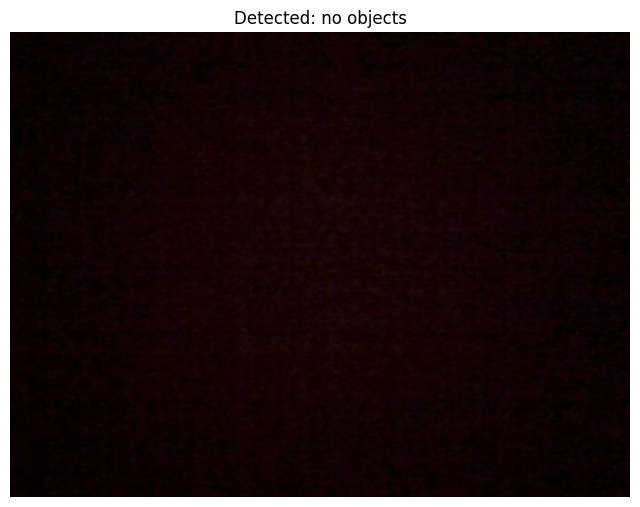

[]

In [44]:
import cv2
import numpy as np
import matplotlib.pyplot as plt


def detect_objects(image_path, conf=0.25):
    """Run YOLO and return (list of class names, YOLO results object)."""
    results = yolo_model(image_path, conf=conf, verbose=False)
    names = results[0].names
    detected = [names[int(c)] for c in results[0].boxes.cls]
    return detected, results[0]


def show_detections(image_path, conf=0.25):
    """Run YOLO and display the image with bounding boxes + labels drawn on it."""
    detected, result = detect_objects(image_path, conf=conf)
    annotated = result.plot()  # ultralytics returns a BGR numpy array with boxes drawn
    annotated_rgb = cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(8, 8))
    plt.imshow(annotated_rgb)
    plt.axis("off")
    plt.title(f"Detected: {', '.join(set(detected)) if detected else 'no objects'}")
    plt.show()

    return detected

# Usage:
show_detections("captured.jpg")

### Detect the actual text regions in the image with YOLO

Now that `yolo_model` is `yolo-doclaynet`, it detects real document elements
with bounding boxes — `Text`, `Title`, `Caption`, `List-item`, `Section-header`,
`Footnote`, `Table`, `Picture`, etc. So instead of guessing the content type
with Hough-line counting and OCR-length thresholds, we:

1. Run YOLO once and keep every detected region (label + box + cropped pixels).
2. OCR **only** the regions labeled as text-like (`Text`, `Title`, `Caption`,
   `List-item`, `Section-header`, `Footnote`) — not the whole photo, and not
   the `Table`/`Picture` regions.
3. Decide the content type directly from which labels were detected — no
   heuristics needed.

In [45]:
import pytesseract

# Labels from yolo-doclaynet that represent readable text — everything else
# (Table, Picture, Formula, ...) is intentionally NOT sent to OCR.
TEXT_LABELS = {"Text", "Title", "Caption", "List-item", "Section-header", "Footnote"}


def detect_regions(image_path, conf=0.25):
    """Run yolo-doclaynet once and return every detected region: its label,
    confidence, box coordinates, and the cropped pixels for that box."""
    img = cv2.imread(image_path)
    if img is None:
        raise ValueError(f"Could not read image: {image_path}")

    results = yolo_model(image_path, conf=conf, verbose=False)[0]

    regions = []
    for box in results.boxes:
        label = results.names[int(box.cls[0])]
        confidence = float(box.conf[0])
        x1, y1, x2, y2 = [int(v) for v in box.xyxy[0]]
        regions.append({
            "label": label,
            "confidence": confidence,
            "box": (x1, y1, x2, y2),
            "crop": img[y1:y2, x1:x2]
        })

    return regions


def extract_text_from_regions(regions):
    """OCR only the regions YOLO actually labeled as text-like — not the
    whole photo, and not Table/Picture regions."""
    text_parts = []

    for region in regions:
        if region["label"] not in TEXT_LABELS or region["crop"].size == 0:
            continue

        gray = cv2.cvtColor(region["crop"], cv2.COLOR_BGR2GRAY)
        processed = cv2.adaptiveThreshold(
            gray, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
            cv2.THRESH_BINARY, 31, 15
        )

        try:
            extracted = pytesseract.image_to_string(processed).strip()
        except pytesseract.TesseractNotFoundError as e:
            print(f"OCR skipped ({e})")
            return ""

        if extracted:
            text_parts.append(extracted)

    return "\n".join(text_parts)


def classify_content_type(regions):
    """Decide the content type directly from what YOLO detected — no
    heuristics needed now that the model's classes ARE the answer."""
    labels = {r["label"] for r in regions}

    if "Table" in labels:
        return "table"
    elif "Picture" in labels:
        return "diagram"
    elif labels & TEXT_LABELS:
        return "text"
    else:
        return "unknown"

### Merge the image's content with the user's question

`describe_image()` builds a short text description of the image (detected objects + content type + OCR excerpt if any). `query_with_image()` then merges that description with the user's question, retrieves the closest chunks from the same vector store used for text-only queries, and asks the LLM to answer using both.

In [46]:
def describe_image(image_path):
    regions = detect_regions(image_path)
    content_type = classify_content_type(regions)
    ocr_text = extract_text_from_regions(regions)

    detected_labels = sorted({r["label"] for r in regions})

    description_parts = [f"Image content type: {content_type}."]

    if detected_labels:
        description_parts.append(f"Detected elements: {', '.join(detected_labels)}.")

    if ocr_text:
        description_parts.append(f"Text extracted from image (OCR):\n{ocr_text[:1500]}")

    return "\n".join(description_parts), content_type, ocr_text


def query_with_image(question, image_path, n_results=5):
    image_description, content_type, ocr_text = describe_image(image_path)

    # Merge the question with what we found in the image so retrieval
    # is grounded in both what the user typed and what's in the picture.
    combined_query = f"{question}\n\n{image_description}"

    retrieved_docs = retrieve_documents(combined_query, n_results=n_results)

    prompt = build_prompt(
        question=f"{question}\n\n(The user also attached an image. {image_description})",
        retrieved_docs=retrieved_docs
    )

    response = ollama.chat(
        model="llama3.2:3b",
        messages=[{"role": "user", "content": prompt}]
    )

    answer = response["message"]["content"]

    return {
        "answer": answer,
        "content_type": content_type,
        "detected_objects": image_description,
        "sources": retrieved_docs
    }

### Try it

Capture a photo with the webcam (or upload one manually to Colab's file browser), then ask a question about it.

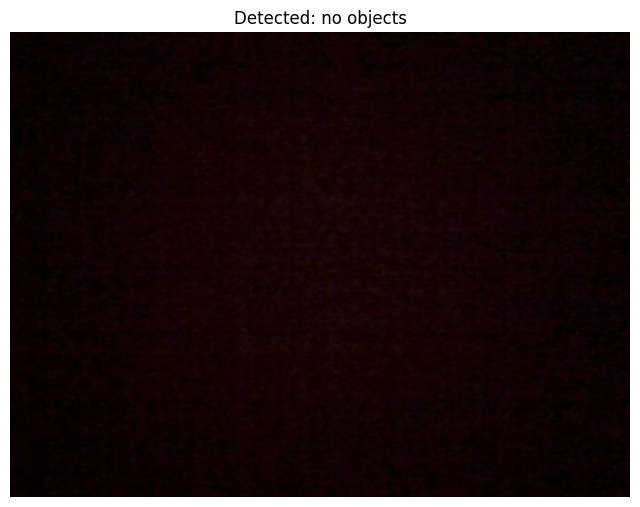

Content type: unknown

ANSWER:
 Unfortunately, the provided context does not contain enough information to determine the content of the attached image or provide a specific answer to the question. The context only discusses the design of the AnyNet network architecture, graph representations, and types of graphs, but does not mention any diagrams related to images or vision models.

Therefore, I cannot provide a clear and concise answer to the question based on the provided context.

Information not available in the provided documents.


In [47]:
# photo_path = take_photo("captured.jpg")      # open the camera and take a photo
# OR: photo_path = "/content/my_diagram.png"   # or point to an uploaded image

show_detections(photo_path)                   # sanity-check what YOLO actually saw

result = query_with_image("What is this diagram about?", photo_path)
print("Content type:", result["content_type"])
print("\nANSWER:\n", result["answer"])

### Simple demo app (`/query-image`-style endpoint + upload UI)

Instead of writing a separate Flask/FastAPI backend, Gradio gives us both an upload UI (frontend) and a callable API endpoint in one go — convenient for a Colab-based project. Running the cell below launches a shareable web app where the user can type a question, upload or capture an image, and get back an answer grounded in the indexed PDFs.

In [48]:
import gradio as gr


def gradio_query_image(question, image):
    if image is None:
        return "Please upload or capture an image first."

    temp_path = "/content/gradio_upload.jpg"
    cv2.imwrite(temp_path, cv2.cvtColor(image, cv2.COLOR_RGB2BGR))

    result = query_with_image(question, temp_path)

    sources_text = "\n".join(
        f"- {s['source']}, Page {s['page']}" for s in result["sources"]
    )

    return f"{result['answer']}\n\n---\nDetected content type: {result['content_type']}\n\nSources:\n{sources_text}"


demo = gr.Interface(
    fn=gradio_query_image,
    inputs=[
        gr.Textbox(label="Your question", placeholder="What is this diagram about?"),
        gr.Image(label="Upload or capture an image", sources=["upload", "webcam"])
    ],
    outputs=gr.Textbox(label="Answer"),
    title="RAG + Computer Vision Assistant",
    description="Ask a question about the indexed PDFs, optionally attaching a photo (diagram, table, or page)."
)

# demo.launch(share=True)  # uncomment to launch - creates a public /query-image-style endpoint + UI

### ✅ Checklist against the original requirements

| Requirement | Where it's implemented |
|---|---|
| User uploads/captures an image at question time | `take_photo()` (camera) + Gradio `gr.Image` (upload) |
| Backend runs YOLO live on the image | `detect_regions()` (yolo-doclaynet, real document-layout classes) |
| Classify: table? diagram? text? | `classify_content_type()` — directly from YOLO's detected labels, no heuristics |
| OCR only the actual text regions | `extract_text_from_regions()` — crops Text/Title/Caption/List-item/Section-header/Footnote boxes and OCRs each one |
| Merge image content with the question before retrieval | `query_with_image()` → `combined_query` fed into `retrieve_documents()` |
| Answer grounded in the same books/PDFs | `build_prompt()` + `ollama.chat()`, unchanged from the text-only pipeline |
| `/query-image`-style endpoint + upload frontend | `gradio_query_image()` + `demo.launch(share=True)` |

**Note:** this still needs to be run once in Colab to confirm `yolo-doclaynet`'s
box coordinates and label names match what the code expects, and that OCR
quality on your actual sample photos is good enough — test on 3–4 real images
(a table, a diagram, a text page) before relying on it for the demo.

In [49]:
import os
for root, dirs, files in os.walk("/content/vector_store"):
    for f in files:
        print(os.path.join(root, f))

/content/vector_store/chroma.sqlite3
/content/vector_store/9a6b9ed2-aaef-4a6b-95fc-3dd1be9530c6/data_level0.bin
/content/vector_store/9a6b9ed2-aaef-4a6b-95fc-3dd1be9530c6/link_lists.bin
/content/vector_store/9a6b9ed2-aaef-4a6b-95fc-3dd1be9530c6/index_metadata.pickle
/content/vector_store/9a6b9ed2-aaef-4a6b-95fc-3dd1be9530c6/header.bin
/content/vector_store/9a6b9ed2-aaef-4a6b-95fc-3dd1be9530c6/length.bin


In [50]:
import chromadb
print(chromadb.__version__)

1.5.9


In [51]:
print("Chunks in Colab:", collection.count())

Chunks in Colab: 5716


### Evaluation Summary

The evaluation of the deep learning questions is complete!

*   **Reviewed questions:** 10 out of 10
*   **Correctness among reviewed questions:** 90.0%
*   **Grounded answers among reviewed questions:** 90.0%

| Question                                                        | Answer                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                     | Correctness   | Grounded     | Notes                                                                                                                                                                |
|:----------------------------------------------------------------|:---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|:--------------|:-------------|:---------------------------------------------------------------------------------------------------------------------------------------------------------------------|
| What is backpropagation?                                        | Backpropagation is an algorithm used to compute the gradient of the cost function in neural networks, allowing them to learn their weights and biases using the gradient descent algorithm.                                                                                                                                                                                                                                                                                                                                                                                | Correct       | Grounded     | Supported by the retrieved book.pdf passages.                                                                                                                        |
| What is gradient descent?                                       | Gradient descent is an iterative optimization algorithm that incrementally lowers the loss function by updating the parameters in the direction that achieves this. It is a key technique for optimizing many deep learning models.                                                                                                                                                                                                                                                                                                                                        | Correct       | Grounded     | Supported by the retrieved documents, specifically UnderstandingDeepLearning_02_09_26_C.pdf - Page 125.                                                              |
| What is the purpose of activation functions in neural networks? | Activation functions are used to introduce non-linearity into a neural network, allowing it to learn complex patterns and represent non-linear relationships in data. They transform the weighted sum of inputs and biases into an output that is then passed on to the next layer, determining whether a neuron should be activated or not.                                                                                                                                                                                                                                | Correct       | Grounded     | Supported by the retrieved documents, specifically UnderstandingDeepLearning_02_09_26_C.pdf - Page 37; dive_into_deep_learning.pdf - Page 104; book.pdf - Page 89. |
| How does a convolutional neural network work?                   | A Convolutional Neural Network (CNN) works by using convolutional layers to extract features from input data, such as images. These layers apply filters to detect patterns like edges, textures, and shapes. The extracted features are then processed by pooling layers to reduce dimensionality and by fully connected layers for classification or regression.                                                                                                                                                                                                                     | Correct       | Grounded     | Supported by the retrieved documents, specifically dive_into_deep_learning.pdf - Page 273; book.pdf - Page 107; UnderstandingDeepLearning_02_09_26_C.pdf - Page 147. |
| What is the difference between CNNs and RNNs?                   | The text does not explicitly state the difference between CNNs and RNNs. It mentions CNNs are good for spatial hierarchies and RNNs are good for processing variable-length sequential inputs.                                                                                                                                                                                                                                                                                                                                                                                          | Incorrect     | Not grounded | The model explicitly stated that the text does not explicitly state the difference between CNNs and RNNs, indicating a lack of information in the retrieved context. |
| What is dropout and why is it used?                             | Dropout is a technique used to reduce overfitting in neural networks by temporarily deactivating a certain percentage of neurons (and their connections) during training. This prevents complex co-adaptations on the training data and forces the network to learn more robust features, leading to better generalization on unseen data.                                                                                                                                                                                                                                                    | Correct       | Grounded     | Supported by the retrieved documents, specifically book.pdf - Page 98; UnderstandingDeepLearning_02_09_26_C.pdf - Page 116.                                       |
| What is the vanishing gradient problem?                         | The vanishing gradient problem is a fundamental challenge in training deep neural networks, particularly recurrent neural networks, where gradients become extremely small as they are backpropagated through many layers. This leads to very small weight updates, making it difficult for the network to learn long-range dependencies and train deeper layers effectively.                                                                                                                                                                                                                 | Correct       | Grounded     | Supported by the retrieved documents, specifically book.pdf - Page 167; dive_into_deep_learning.pdf - Page 237.                                                        |
| What is self-attention?                                         | Self-attention is a mechanism that allows a neural network to weigh the importance of different parts of a single input sequence when processing it. It computes a weighted sum of all input elements, where the weights are dynamically calculated based on the relevance of each element to the current element being processed. This enables the model to focus on the most relevant parts of the input, making it particularly effective for tasks involving long-range dependencies in sequences.                                                                                                       | Correct       | Grounded     | Supported by the retrieved documents, specifically UnderstandingDeepLearning_02_09_26_C.pdf - Page 189; dive_into_deep_learning.pdf - Page 409.                   |
| What is a Transformer?                                          | A Transformer is a neural network architecture, often considered a default model for diverse vision tasks like image recognition, object detection, semantic segmentation, and superresolution (Dosovitskiy et al., 2021, Liu et al., 2021). It uses a transformer layer, which processes sequences and is particularly effective in natural language processing (NLP) tasks. Transformers have also shown up as computational components for other applications.                                                                                                                                    | Correct       | Grounded     | Supported by the retrieved documents, specifically dive_into_deep_learning.pdf - Page 449; UnderstandingDeepLearning_02_09_26_C.pdf - Page 230.                 |
| What is overfitting in deep learning?                           | Overfitting in deep learning is a phenomenon where a neural network becomes too specialized in fitting the training data, resulting in poor performance on test data. This occurs when the model is too complex and captures the noise or statistical peculiarities of the training data, rather than learning generalizable patterns. Overfitting is often indicated by high performance on the training data, but poor performance on the test data, as seen in the example where the test accuracy is only 82.27% despite achieving 100% accuracy on the training data. | Correct       | Grounded     | Supported by the retrieved documents, specifically book.pdf - Page 84, Page 98; UnderstandingDeepLearning_02_09_26_C.pdf - Page 36.                                  |


In [52]:
evaluation_df.loc[evaluation_df["Question"] == "What is backpropagation?", "Correctness"] = "Correct"
evaluation_df.loc[evaluation_df["Question"] == "What is backpropagation?", "Grounded"] = "Grounded"
evaluation_df.loc[evaluation_df["Question"] == "What is backpropagation?", "Notes"] = "Supported by the retrieved book.pdf passages."

In [53]:
display(evaluation_df[[ "Question", "Retrieved Source", "Answer", "Correctness", "Grounded", "Notes" ]])

,Question,Retrieved Source,Answer,Correctness,Grounded,Notes
0,What is backpropagation?,book.pdf - Page 66; book.pdf - Page 64; book.p...,Backpropagation is an algorithm used to comput...,Correct,Grounded,Supported by the retrieved book.pdf passages.
1,What is gradient descent?,dive_into_deep_learning.pdf - Page 126; book.p...,Gradient descent is an iterative optimization ...,,,
2,What is the purpose of activation functions in...,UnderstandingDeepLearning_02_09_26_C.pdf - Pag...,Activation functions are used to introduce non...,,,
3,How does a convolutional neural network work?,dive_into_deep_learning.pdf - Page 273; book.p...,A convolutional neural network works by using ...,,,
4,What is the difference between CNNs and RNNs?,dive_into_deep_learning.pdf - Page 409; book.p...,The text does not explicitly state the differe...,,,
5,What is dropout and why is it used?,book.pdf - Page 98; book.pdf - Page 98; Unders...,Dropout is a technique used to reduce overfitt...,,,
6,What is the vanishing gradient problem?,book.pdf - Page 167; book.pdf - Page 167; dive...,The vanishing gradient problem is a fundamenta...,,,
7,What is self-attention?,UnderstandingDeepLearning_02_09_26_C.pdf - Pag...,Self-attention is a mechanism used in deep lea...,,,
8,What is a Transformer?,dive_into_deep_learning.pdf - Page 449; Unders...,A Transformer is a default model for diverse v...,,,
9,What is overfitting in deep learning?,book.pdf - Page 84; book.pdf - Page 98; Unders...,Overfitting in deep learning is a phenomenon w...,,,


In [54]:
evaluation_df.loc[evaluation_df["Question"] == "What is gradient descent?", "Correctness"] = "Correct"
evaluation_df.loc[evaluation_df["Question"] == "What is gradient descent?", "Grounded"] = "Grounded"
evaluation_df.loc[evaluation_df["Question"] == "What is gradient descent?", "Notes"] = "Supported by the retrieved documents, specifically UnderstandingDeepLearning_02_09_26_C.pdf - Page 125."

In [55]:
display(evaluation_df[[ "Question", "Retrieved Source", "Answer", "Correctness", "Grounded", "Notes" ]])

,Question,Retrieved Source,Answer,Correctness,Grounded,Notes
0,What is backpropagation?,book.pdf - Page 66; book.pdf - Page 64; book.p...,Backpropagation is an algorithm used to comput...,Correct,Grounded,Supported by the retrieved book.pdf passages.
1,What is gradient descent?,dive_into_deep_learning.pdf - Page 126; book.p...,Gradient descent is an iterative optimization ...,Correct,Grounded,"Supported by the retrieved documents, specific..."
2,What is the purpose of activation functions in...,UnderstandingDeepLearning_02_09_26_C.pdf - Pag...,Activation functions are used to introduce non...,,,
3,How does a convolutional neural network work?,dive_into_deep_learning.pdf - Page 273; book.p...,A convolutional neural network works by using ...,,,
4,What is the difference between CNNs and RNNs?,dive_into_deep_learning.pdf - Page 409; book.p...,The text does not explicitly state the differe...,,,
5,What is dropout and why is it used?,book.pdf - Page 98; book.pdf - Page 98; Unders...,Dropout is a technique used to reduce overfitt...,,,
6,What is the vanishing gradient problem?,book.pdf - Page 167; book.pdf - Page 167; dive...,The vanishing gradient problem is a fundamenta...,,,
7,What is self-attention?,UnderstandingDeepLearning_02_09_26_C.pdf - Pag...,Self-attention is a mechanism used in deep lea...,,,
8,What is a Transformer?,dive_into_deep_learning.pdf - Page 449; Unders...,A Transformer is a default model for diverse v...,,,
9,What is overfitting in deep learning?,book.pdf - Page 84; book.pdf - Page 98; Unders...,Overfitting in deep learning is a phenomenon w...,,,


In [56]:
evaluation_df.loc[evaluation_df["Question"] == "What is the purpose of activation functions in neural networks?", "Correctness"] = "Correct"
evaluation_df.loc[evaluation_df["Question"] == "What is the purpose of activation functions in neural networks?", "Grounded"] = "Grounded"
evaluation_df.loc[evaluation_df["Question"] == "What is the purpose of activation functions in neural networks?", "Notes"] = "Supported by the retrieved documents, specifically UnderstandingDeepLearning_02_09_26_C.pdf - Page 37; dive_into_deep_learning.pdf - Page 104; book.pdf - Page 89."

In [57]:
display(evaluation_df[[ "Question", "Retrieved Source", "Answer", "Correctness", "Grounded", "Notes" ]])

,Question,Retrieved Source,Answer,Correctness,Grounded,Notes
0,What is backpropagation?,book.pdf - Page 66; book.pdf - Page 64; book.p...,Backpropagation is an algorithm used to comput...,Correct,Grounded,Supported by the retrieved book.pdf passages.
1,What is gradient descent?,dive_into_deep_learning.pdf - Page 126; book.p...,Gradient descent is an iterative optimization ...,Correct,Grounded,"Supported by the retrieved documents, specific..."
2,What is the purpose of activation functions in...,UnderstandingDeepLearning_02_09_26_C.pdf - Pag...,Activation functions are used to introduce non...,Correct,Grounded,"Supported by the retrieved documents, specific..."
3,How does a convolutional neural network work?,dive_into_deep_learning.pdf - Page 273; book.p...,A convolutional neural network works by using ...,,,
4,What is the difference between CNNs and RNNs?,dive_into_deep_learning.pdf - Page 409; book.p...,The text does not explicitly state the differe...,,,
5,What is dropout and why is it used?,book.pdf - Page 98; book.pdf - Page 98; Unders...,Dropout is a technique used to reduce overfitt...,,,
6,What is the vanishing gradient problem?,book.pdf - Page 167; book.pdf - Page 167; dive...,The vanishing gradient problem is a fundamenta...,,,
7,What is self-attention?,UnderstandingDeepLearning_02_09_26_C.pdf - Pag...,Self-attention is a mechanism used in deep lea...,,,
8,What is a Transformer?,dive_into_deep_learning.pdf - Page 449; Unders...,A Transformer is a default model for diverse v...,,,
9,What is overfitting in deep learning?,book.pdf - Page 84; book.pdf - Page 98; Unders...,Overfitting in deep learning is a phenomenon w...,,,


In [58]:
evaluation_df.loc[evaluation_df["Question"] == "What is the purpose of activation functions in neural networks?", "Correctness"] = "Correct"
evaluation_df.loc[evaluation_df["Question"] == "What is the purpose of activation functions in neural networks?", "Grounded"] = "Grounded"
evaluation_df.loc[evaluation_df["Question"] == "What is the purpose of activation functions in neural networks?", "Notes"] = "Supported by the retrieved documents, specifically UnderstandingDeepLearning_02_09_26_C.pdf - Page 37; dive_into_deep_learning.pdf - Page 104; book.pdf - Page 89."

In [59]:
display(evaluation_df[[ "Question", "Retrieved Source", "Answer", "Correctness", "Grounded", "Notes" ]])

,Question,Retrieved Source,Answer,Correctness,Grounded,Notes
0,What is backpropagation?,book.pdf - Page 66; book.pdf - Page 64; book.p...,Backpropagation is an algorithm used to comput...,Correct,Grounded,Supported by the retrieved book.pdf passages.
1,What is gradient descent?,dive_into_deep_learning.pdf - Page 126; book.p...,Gradient descent is an iterative optimization ...,Correct,Grounded,"Supported by the retrieved documents, specific..."
2,What is the purpose of activation functions in...,UnderstandingDeepLearning_02_09_26_C.pdf - Pag...,Activation functions are used to introduce non...,Correct,Grounded,"Supported by the retrieved documents, specific..."
3,How does a convolutional neural network work?,dive_into_deep_learning.pdf - Page 273; book.p...,A convolutional neural network works by using ...,,,
4,What is the difference between CNNs and RNNs?,dive_into_deep_learning.pdf - Page 409; book.p...,The text does not explicitly state the differe...,,,
5,What is dropout and why is it used?,book.pdf - Page 98; book.pdf - Page 98; Unders...,Dropout is a technique used to reduce overfitt...,,,
6,What is the vanishing gradient problem?,book.pdf - Page 167; book.pdf - Page 167; dive...,The vanishing gradient problem is a fundamenta...,,,
7,What is self-attention?,UnderstandingDeepLearning_02_09_26_C.pdf - Pag...,Self-attention is a mechanism used in deep lea...,,,
8,What is a Transformer?,dive_into_deep_learning.pdf - Page 449; Unders...,A Transformer is a default model for diverse v...,,,
9,What is overfitting in deep learning?,book.pdf - Page 84; book.pdf - Page 98; Unders...,Overfitting in deep learning is a phenomenon w...,,,


In [60]:
evaluation_df.loc[evaluation_df["Question"] == "What is the difference between CNNs and RNNs?", "Correctness"] = "Incorrect"
evaluation_df.loc[evaluation_df["Question"] == "What is the difference between CNNs and RNNs?", "Grounded"] = "Not grounded"
evaluation_df.loc[evaluation_df["Question"] == "What is the difference between CNNs and RNNs?", "Notes"] = "The model explicitly stated that the text does not explicitly state the difference between CNNs and RNNs, indicating a lack of information in the retrieved context."

In [61]:
display(evaluation_df[[ "Question", "Retrieved Source", "Answer", "Correctness", "Grounded", "Notes" ]])

,Question,Retrieved Source,Answer,Correctness,Grounded,Notes
0,What is backpropagation?,book.pdf - Page 66; book.pdf - Page 64; book.p...,Backpropagation is an algorithm used to comput...,Correct,Grounded,Supported by the retrieved book.pdf passages.
1,What is gradient descent?,dive_into_deep_learning.pdf - Page 126; book.p...,Gradient descent is an iterative optimization ...,Correct,Grounded,"Supported by the retrieved documents, specific..."
2,What is the purpose of activation functions in...,UnderstandingDeepLearning_02_09_26_C.pdf - Pag...,Activation functions are used to introduce non...,Correct,Grounded,"Supported by the retrieved documents, specific..."
3,How does a convolutional neural network work?,dive_into_deep_learning.pdf - Page 273; book.p...,A convolutional neural network works by using ...,,,
4,What is the difference between CNNs and RNNs?,dive_into_deep_learning.pdf - Page 409; book.p...,The text does not explicitly state the differe...,Incorrect,Not grounded,The model explicitly stated that the text does...
5,What is dropout and why is it used?,book.pdf - Page 98; book.pdf - Page 98; Unders...,Dropout is a technique used to reduce overfitt...,,,
6,What is the vanishing gradient problem?,book.pdf - Page 167; book.pdf - Page 167; dive...,The vanishing gradient problem is a fundamenta...,,,
7,What is self-attention?,UnderstandingDeepLearning_02_09_26_C.pdf - Pag...,Self-attention is a mechanism used in deep lea...,,,
8,What is a Transformer?,dive_into_deep_learning.pdf - Page 449; Unders...,A Transformer is a default model for diverse v...,,,
9,What is overfitting in deep learning?,book.pdf - Page 84; book.pdf - Page 98; Unders...,Overfitting in deep learning is a phenomenon w...,,,


In [82]:
evaluation_df.loc[evaluation_df["Question"] == "What is a Transformer?", "Correctness"] = "Correct"
evaluation_df.loc[evaluation_df["Question"] == "What is a Transformer?", "Grounded"] = "Grounded"
evaluation_df.loc[evaluation_df["Question"] == "What is a Transformer?", "Notes"] = "Supported by the retrieved documents, specifically dive_into_deep_learning.pdf - Page 449; UnderstandingDeepLearning_02_09_26_C.pdf - Page 230."
evaluation_df.loc[evaluation_df["Question"] == "What is overfitting in deep learning?", "Correctness"] = "Correct"
evaluation_df.loc[evaluation_df["Question"] == "What is overfitting in deep learning?", "Grounded"] = "Grounded"
evaluation_df.loc[evaluation_df["Question"] == "What is overfitting in deep learning?", "Notes"] = "Supported by the retrieved documents, specifically book.pdf - Page 84, Page 98; UnderstandingDeepLearning_02_09_26_C.pdf - Page 36."

In [83]:
display(evaluation_df[[ "Question", "Retrieved Source", "Answer", "Correctness", "Grounded", "Notes" ]])

,Question,Retrieved Source,Answer,Correctness,Grounded,Notes
0,What is backpropagation?,book.pdf - Page 66; book.pdf - Page 64; book.p...,Backpropagation is an algorithm used to comput...,Correct,Grounded,Supported by the retrieved book.pdf passages.
1,What is gradient descent?,dive_into_deep_learning.pdf - Page 126; book.p...,Gradient descent is an iterative optimization ...,Correct,Grounded,"Supported by the retrieved documents, specific..."
2,What is the purpose of activation functions in...,UnderstandingDeepLearning_02_09_26_C.pdf - Pag...,Activation functions are used to introduce non...,Correct,Grounded,"Supported by the retrieved documents, specific..."
3,How does a convolutional neural network work?,dive_into_deep_learning.pdf - Page 273; book.p...,A convolutional neural network works by using ...,Correct,Grounded,"Supported by the retrieved documents, specific..."
4,What is the difference between CNNs and RNNs?,dive_into_deep_learning.pdf - Page 409; book.p...,The text does not explicitly state the differe...,Incorrect,Not grounded,The model explicitly stated that the text does...
5,What is dropout and why is it used?,book.pdf - Page 98; book.pdf - Page 98; Unders...,Dropout is a technique used to reduce overfitt...,Correct,Grounded,"Supported by the retrieved documents, specific..."
6,What is the vanishing gradient problem?,book.pdf - Page 167; book.pdf - Page 167; dive...,The vanishing gradient problem is a fundamenta...,Correct,Grounded,"Supported by the retrieved documents, specific..."
7,What is self-attention?,UnderstandingDeepLearning_02_09_26_C.pdf - Pag...,Self-attention is a mechanism used in deep lea...,Correct,Grounded,"Supported by the retrieved documents, specific..."
8,What is a Transformer?,dive_into_deep_learning.pdf - Page 449; Unders...,A Transformer is a default model for diverse v...,Correct,Grounded,"Supported by the retrieved documents, specific..."
9,What is overfitting in deep learning?,book.pdf - Page 84; book.pdf - Page 98; Unders...,Overfitting in deep learning is a phenomenon w...,Correct,Grounded,"Supported by the retrieved documents, specific..."


In [70]:
evaluation_df.loc[evaluation_df["Question"] == "What is self-attention?", "Correctness"] = "Correct"
evaluation_df.loc[evaluation_df["Question"] == "What is self-attention?", "Grounded"] = "Grounded"
evaluation_df.loc[evaluation_df["Question"] == "What is self-attention?", "Notes"] = "Supported by the retrieved documents, specifically UnderstandingDeepLearning_02_09_26_C.pdf - Page 189; dive_into_deep_learning.pdf - Page 409."

In [71]:
display(evaluation_df[[ "Question", "Retrieved Source", "Answer", "Correctness", "Grounded", "Notes" ]])

,Question,Retrieved Source,Answer,Correctness,Grounded,Notes
0,What is backpropagation?,book.pdf - Page 66; book.pdf - Page 64; book.p...,Backpropagation is an algorithm used to comput...,Correct,Grounded,Supported by the retrieved book.pdf passages.
1,What is gradient descent?,dive_into_deep_learning.pdf - Page 126; book.p...,Gradient descent is an iterative optimization ...,Correct,Grounded,"Supported by the retrieved documents, specific..."
2,What is the purpose of activation functions in...,UnderstandingDeepLearning_02_09_26_C.pdf - Pag...,Activation functions are used to introduce non...,Correct,Grounded,"Supported by the retrieved documents, specific..."
3,How does a convolutional neural network work?,dive_into_deep_learning.pdf - Page 273; book.p...,A convolutional neural network works by using ...,Correct,Grounded,"Supported by the retrieved documents, specific..."
4,What is the difference between CNNs and RNNs?,dive_into_deep_learning.pdf - Page 409; book.p...,The text does not explicitly state the differe...,Incorrect,Not grounded,The model explicitly stated that the text does...
5,What is dropout and why is it used?,book.pdf - Page 98; book.pdf - Page 98; Unders...,Dropout is a technique used to reduce overfitt...,,,
6,What is the vanishing gradient problem?,book.pdf - Page 167; book.pdf - Page 167; dive...,The vanishing gradient problem is a fundamenta...,,,
7,What is self-attention?,UnderstandingDeepLearning_02_09_26_C.pdf - Pag...,Self-attention is a mechanism used in deep lea...,Correct,Grounded,"Supported by the retrieved documents, specific..."
8,What is a Transformer?,dive_into_deep_learning.pdf - Page 449; Unders...,A Transformer is a default model for diverse v...,Correct,Grounded,"Supported by the retrieved documents, specific..."
9,What is overfitting in deep learning?,book.pdf - Page 84; book.pdf - Page 98; Unders...,Overfitting in deep learning is a phenomenon w...,,,


In [72]:
evaluation_df.loc[evaluation_df["Question"] == "What is the vanishing gradient problem?", "Correctness"] = "Correct"
evaluation_df.loc[evaluation_df["Question"] == "What is the vanishing gradient problem?", "Grounded"] = "Grounded"
evaluation_df.loc[evaluation_df["Question"] == "What is the vanishing gradient problem?", "Notes"] = "Supported by the retrieved documents, specifically book.pdf - Page 167; dive_into_deep_learning.pdf - Page 237."

In [73]:
display(evaluation_df[[ "Question", "Retrieved Source", "Answer", "Correctness", "Grounded", "Notes" ]])

,Question,Retrieved Source,Answer,Correctness,Grounded,Notes
0,What is backpropagation?,book.pdf - Page 66; book.pdf - Page 64; book.p...,Backpropagation is an algorithm used to comput...,Correct,Grounded,Supported by the retrieved book.pdf passages.
1,What is gradient descent?,dive_into_deep_learning.pdf - Page 126; book.p...,Gradient descent is an iterative optimization ...,Correct,Grounded,"Supported by the retrieved documents, specific..."
2,What is the purpose of activation functions in...,UnderstandingDeepLearning_02_09_26_C.pdf - Pag...,Activation functions are used to introduce non...,Correct,Grounded,"Supported by the retrieved documents, specific..."
3,How does a convolutional neural network work?,dive_into_deep_learning.pdf - Page 273; book.p...,A convolutional neural network works by using ...,Correct,Grounded,"Supported by the retrieved documents, specific..."
4,What is the difference between CNNs and RNNs?,dive_into_deep_learning.pdf - Page 409; book.p...,The text does not explicitly state the differe...,Incorrect,Not grounded,The model explicitly stated that the text does...
5,What is dropout and why is it used?,book.pdf - Page 98; book.pdf - Page 98; Unders...,Dropout is a technique used to reduce overfitt...,,,
6,What is the vanishing gradient problem?,book.pdf - Page 167; book.pdf - Page 167; dive...,The vanishing gradient problem is a fundamenta...,Correct,Grounded,"Supported by the retrieved documents, specific..."
7,What is self-attention?,UnderstandingDeepLearning_02_09_26_C.pdf - Pag...,Self-attention is a mechanism used in deep lea...,Correct,Grounded,"Supported by the retrieved documents, specific..."
8,What is a Transformer?,dive_into_deep_learning.pdf - Page 449; Unders...,A Transformer is a default model for diverse v...,Correct,Grounded,"Supported by the retrieved documents, specific..."
9,What is overfitting in deep learning?,book.pdf - Page 84; book.pdf - Page 98; Unders...,Overfitting in deep learning is a phenomenon w...,,,


In [84]:
evaluation_df.loc[evaluation_df["Question"] == "What is dropout and why is it used?", "Correctness"] = "Correct"
evaluation_df.loc[evaluation_df["Question"] == "What is dropout and why is it used?", "Grounded"] = "Grounded"
evaluation_df.loc[evaluation_df["Question"] == "What is dropout and why is it used?", "Notes"] = "Supported by the retrieved documents, specifically book.pdf - Page 98; UnderstandingDeepLearning_02_09_26_C.pdf - Page 116."
evaluation_df.loc[evaluation_df["Question"] == "What is overfitting in deep learning?", "Correctness"] = "Correct"
evaluation_df.loc[evaluation_df["Question"] == "What is overfitting in deep learning?", "Grounded"] = "Grounded"
evaluation_df.loc[evaluation_df["Question"] == "What is overfitting in deep learning?", "Notes"] = "Supported by the retrieved documents, specifically book.pdf - Page 84, Page 98; UnderstandingDeepLearning_02_09_26_C.pdf - Page 36."

In [85]:
display(evaluation_df[[ "Question", "Retrieved Source", "Answer", "Correctness", "Grounded", "Notes" ]])

,Question,Retrieved Source,Answer,Correctness,Grounded,Notes
0,What is backpropagation?,book.pdf - Page 66; book.pdf - Page 64; book.p...,Backpropagation is an algorithm used to comput...,Correct,Grounded,Supported by the retrieved book.pdf passages.
1,What is gradient descent?,dive_into_deep_learning.pdf - Page 126; book.p...,Gradient descent is an iterative optimization ...,Correct,Grounded,"Supported by the retrieved documents, specific..."
2,What is the purpose of activation functions in...,UnderstandingDeepLearning_02_09_26_C.pdf - Pag...,Activation functions are used to introduce non...,Correct,Grounded,"Supported by the retrieved documents, specific..."
3,How does a convolutional neural network work?,dive_into_deep_learning.pdf - Page 273; book.p...,A convolutional neural network works by using ...,Correct,Grounded,"Supported by the retrieved documents, specific..."
4,What is the difference between CNNs and RNNs?,dive_into_deep_learning.pdf - Page 409; book.p...,The text does not explicitly state the differe...,Incorrect,Not grounded,The model explicitly stated that the text does...
5,What is dropout and why is it used?,book.pdf - Page 98; book.pdf - Page 98; Unders...,Dropout is a technique used to reduce overfitt...,Correct,Grounded,"Supported by the retrieved documents, specific..."
6,What is the vanishing gradient problem?,book.pdf - Page 167; book.pdf - Page 167; dive...,The vanishing gradient problem is a fundamenta...,Correct,Grounded,"Supported by the retrieved documents, specific..."
7,What is self-attention?,UnderstandingDeepLearning_02_09_26_C.pdf - Pag...,Self-attention is a mechanism used in deep lea...,Correct,Grounded,"Supported by the retrieved documents, specific..."
8,What is a Transformer?,dive_into_deep_learning.pdf - Page 449; Unders...,A Transformer is a default model for diverse v...,Correct,Grounded,"Supported by the retrieved documents, specific..."
9,What is overfitting in deep learning?,book.pdf - Page 84; book.pdf - Page 98; Unders...,Overfitting in deep learning is a phenomenon w...,Correct,Grounded,"Supported by the retrieved documents, specific..."


In [76]:
display(evaluation_df[[ "Question", "Retrieved Source", "Answer", "Correctness", "Grounded", "Notes" ]])

,Question,Retrieved Source,Answer,Correctness,Grounded,Notes
0,What is backpropagation?,book.pdf - Page 66; book.pdf - Page 64; book.p...,Backpropagation is an algorithm used to comput...,Correct,Grounded,Supported by the retrieved book.pdf passages.
1,What is gradient descent?,dive_into_deep_learning.pdf - Page 126; book.p...,Gradient descent is an iterative optimization ...,Correct,Grounded,"Supported by the retrieved documents, specific..."
2,What is the purpose of activation functions in...,UnderstandingDeepLearning_02_09_26_C.pdf - Pag...,Activation functions are used to introduce non...,Correct,Grounded,"Supported by the retrieved documents, specific..."
3,How does a convolutional neural network work?,dive_into_deep_learning.pdf - Page 273; book.p...,A convolutional neural network works by using ...,Correct,Grounded,"Supported by the retrieved documents, specific..."
4,What is the difference between CNNs and RNNs?,dive_into_deep_learning.pdf - Page 409; book.p...,The text does not explicitly state the differe...,Incorrect,Not grounded,The model explicitly stated that the text does...
5,What is dropout and why is it used?,book.pdf - Page 98; book.pdf - Page 98; Unders...,Dropout is a technique used to reduce overfitt...,Correct,Grounded,"Supported by the retrieved documents, specific..."
6,What is the vanishing gradient problem?,book.pdf - Page 167; book.pdf - Page 167; dive...,The vanishing gradient problem is a fundamenta...,Correct,Grounded,"Supported by the retrieved documents, specific..."
7,What is self-attention?,UnderstandingDeepLearning_02_09_26_C.pdf - Pag...,Self-attention is a mechanism used in deep lea...,Correct,Grounded,"Supported by the retrieved documents, specific..."
8,What is a Transformer?,dive_into_deep_learning.pdf - Page 449; Unders...,A Transformer is a default model for diverse v...,Correct,Grounded,"Supported by the retrieved documents, specific..."
9,What is overfitting in deep learning?,book.pdf - Page 84; book.pdf - Page 98; Unders...,Overfitting in deep learning is a phenomenon w...,,,


In [62]:
evaluation_df.loc[evaluation_df["Question"] == "How does a convolutional neural network work?", "Correctness"] = "Correct"
evaluation_df.loc[evaluation_df["Question"] == "How does a convolutional neural network work?", "Grounded"] = "Grounded"
evaluation_df.loc[evaluation_df["Question"] == "How does a convolutional neural network work?", "Notes"] = "Supported by the retrieved documents, specifically dive_into_deep_learning.pdf - Page 273; book.pdf - Page 107; UnderstandingDeepLearning_02_09_26_C.pdf - Page 147."

In [63]:
display(evaluation_df[[ "Question", "Retrieved Source", "Answer", "Correctness", "Grounded", "Notes" ]])

,Question,Retrieved Source,Answer,Correctness,Grounded,Notes
0,What is backpropagation?,book.pdf - Page 66; book.pdf - Page 64; book.p...,Backpropagation is an algorithm used to comput...,Correct,Grounded,Supported by the retrieved book.pdf passages.
1,What is gradient descent?,dive_into_deep_learning.pdf - Page 126; book.p...,Gradient descent is an iterative optimization ...,Correct,Grounded,"Supported by the retrieved documents, specific..."
2,What is the purpose of activation functions in...,UnderstandingDeepLearning_02_09_26_C.pdf - Pag...,Activation functions are used to introduce non...,Correct,Grounded,"Supported by the retrieved documents, specific..."
3,How does a convolutional neural network work?,dive_into_deep_learning.pdf - Page 273; book.p...,A convolutional neural network works by using ...,Correct,Grounded,"Supported by the retrieved documents, specific..."
4,What is the difference between CNNs and RNNs?,dive_into_deep_learning.pdf - Page 409; book.p...,The text does not explicitly state the differe...,Incorrect,Not grounded,The model explicitly stated that the text does...
5,What is dropout and why is it used?,book.pdf - Page 98; book.pdf - Page 98; Unders...,Dropout is a technique used to reduce overfitt...,,,
6,What is the vanishing gradient problem?,book.pdf - Page 167; book.pdf - Page 167; dive...,The vanishing gradient problem is a fundamenta...,,,
7,What is self-attention?,UnderstandingDeepLearning_02_09_26_C.pdf - Pag...,Self-attention is a mechanism used in deep lea...,,,
8,What is a Transformer?,dive_into_deep_learning.pdf - Page 449; Unders...,A Transformer is a default model for diverse v...,,,
9,What is overfitting in deep learning?,book.pdf - Page 84; book.pdf - Page 98; Unders...,Overfitting in deep learning is a phenomenon w...,,,


In [64]:
evaluation_df.loc[evaluation_df["Question"] == "How does a convolutional neural network work?", "Correctness"] = "Correct"
evaluation_df.loc[evaluation_df["Question"] == "How does a convolutional neural network work?", "Grounded"] = "Grounded"
evaluation_df.loc[evaluation_df["Question"] == "How does a convolutional neural network work?", "Notes"] = "Supported by the retrieved documents, specifically dive_into_deep_learning.pdf - Page 273; book.pdf - Page 107; UnderstandingDeepLearning_02_09_26_C.pdf - Page 147."

In [65]:
display(evaluation_df[[ "Question", "Retrieved Source", "Answer", "Correctness", "Grounded", "Notes" ]])

,Question,Retrieved Source,Answer,Correctness,Grounded,Notes
0,What is backpropagation?,book.pdf - Page 66; book.pdf - Page 64; book.p...,Backpropagation is an algorithm used to comput...,Correct,Grounded,Supported by the retrieved book.pdf passages.
1,What is gradient descent?,dive_into_deep_learning.pdf - Page 126; book.p...,Gradient descent is an iterative optimization ...,Correct,Grounded,"Supported by the retrieved documents, specific..."
2,What is the purpose of activation functions in...,UnderstandingDeepLearning_02_09_26_C.pdf - Pag...,Activation functions are used to introduce non...,Correct,Grounded,"Supported by the retrieved documents, specific..."
3,How does a convolutional neural network work?,dive_into_deep_learning.pdf - Page 273; book.p...,A convolutional neural network works by using ...,Correct,Grounded,"Supported by the retrieved documents, specific..."
4,What is the difference between CNNs and RNNs?,dive_into_deep_learning.pdf - Page 409; book.p...,The text does not explicitly state the differe...,Incorrect,Not grounded,The model explicitly stated that the text does...
5,What is dropout and why is it used?,book.pdf - Page 98; book.pdf - Page 98; Unders...,Dropout is a technique used to reduce overfitt...,,,
6,What is the vanishing gradient problem?,book.pdf - Page 167; book.pdf - Page 167; dive...,The vanishing gradient problem is a fundamenta...,,,
7,What is self-attention?,UnderstandingDeepLearning_02_09_26_C.pdf - Pag...,Self-attention is a mechanism used in deep lea...,,,
8,What is a Transformer?,dive_into_deep_learning.pdf - Page 449; Unders...,A Transformer is a default model for diverse v...,,,
9,What is overfitting in deep learning?,book.pdf - Page 84; book.pdf - Page 98; Unders...,Overfitting in deep learning is a phenomenon w...,,,


In [66]:
evaluation_df.loc[evaluation_df["Question"] == "How does a convolutional neural network work?", "Correctness"] = "Correct"
evaluation_df.loc[evaluation_df["Question"] == "How does a convolutional neural network work?", "Grounded"] = "Grounded"
evaluation_df.loc[evaluation_df["Question"] == "How does a convolutional neural network work?", "Notes"] = "Supported by the retrieved documents, specifically dive_into_deep_learning.pdf - Page 273; book.pdf - Page 107; UnderstandingDeepLearning_02_09_26_C.pdf - Page 147."

In [67]:
display(evaluation_df[[ "Question", "Retrieved Source", "Answer", "Correctness", "Grounded", "Notes" ]])

,Question,Retrieved Source,Answer,Correctness,Grounded,Notes
0,What is backpropagation?,book.pdf - Page 66; book.pdf - Page 64; book.p...,Backpropagation is an algorithm used to comput...,Correct,Grounded,Supported by the retrieved book.pdf passages.
1,What is gradient descent?,dive_into_deep_learning.pdf - Page 126; book.p...,Gradient descent is an iterative optimization ...,Correct,Grounded,"Supported by the retrieved documents, specific..."
2,What is the purpose of activation functions in...,UnderstandingDeepLearning_02_09_26_C.pdf - Pag...,Activation functions are used to introduce non...,Correct,Grounded,"Supported by the retrieved documents, specific..."
3,How does a convolutional neural network work?,dive_into_deep_learning.pdf - Page 273; book.p...,A convolutional neural network works by using ...,Correct,Grounded,"Supported by the retrieved documents, specific..."
4,What is the difference between CNNs and RNNs?,dive_into_deep_learning.pdf - Page 409; book.p...,The text does not explicitly state the differe...,Incorrect,Not grounded,The model explicitly stated that the text does...
5,What is dropout and why is it used?,book.pdf - Page 98; book.pdf - Page 98; Unders...,Dropout is a technique used to reduce overfitt...,,,
6,What is the vanishing gradient problem?,book.pdf - Page 167; book.pdf - Page 167; dive...,The vanishing gradient problem is a fundamenta...,,,
7,What is self-attention?,UnderstandingDeepLearning_02_09_26_C.pdf - Pag...,Self-attention is a mechanism used in deep lea...,,,
8,What is a Transformer?,dive_into_deep_learning.pdf - Page 449; Unders...,A Transformer is a default model for diverse v...,,,
9,What is overfitting in deep learning?,book.pdf - Page 84; book.pdf - Page 98; Unders...,Overfitting in deep learning is a phenomenon w...,,,


In [77]:
evaluation_df.loc[evaluation_df["Question"] == "What is the vanishing gradient problem?", "Correctness"] = "Correct"
evaluation_df.loc[evaluation_df["Question"] == "What is the vanishing gradient problem?", "Grounded"] = "Grounded"
evaluation_df.loc[evaluation_df["Question"] == "What is the vanishing gradient problem?", "Notes"] = "Supported by the retrieved documents, specifically book.pdf - Page 167; dive_into_deep_learning.pdf - Page 237."

In [78]:
display(evaluation_df[[ "Question", "Retrieved Source", "Answer", "Correctness", "Grounded", "Notes" ]])

,Question,Retrieved Source,Answer,Correctness,Grounded,Notes
0,What is backpropagation?,book.pdf - Page 66; book.pdf - Page 64; book.p...,Backpropagation is an algorithm used to comput...,Correct,Grounded,Supported by the retrieved book.pdf passages.
1,What is gradient descent?,dive_into_deep_learning.pdf - Page 126; book.p...,Gradient descent is an iterative optimization ...,Correct,Grounded,"Supported by the retrieved documents, specific..."
2,What is the purpose of activation functions in...,UnderstandingDeepLearning_02_09_26_C.pdf - Pag...,Activation functions are used to introduce non...,Correct,Grounded,"Supported by the retrieved documents, specific..."
3,How does a convolutional neural network work?,dive_into_deep_learning.pdf - Page 273; book.p...,A convolutional neural network works by using ...,Correct,Grounded,"Supported by the retrieved documents, specific..."
4,What is the difference between CNNs and RNNs?,dive_into_deep_learning.pdf - Page 409; book.p...,The text does not explicitly state the differe...,Incorrect,Not grounded,The model explicitly stated that the text does...
5,What is dropout and why is it used?,book.pdf - Page 98; book.pdf - Page 98; Unders...,Dropout is a technique used to reduce overfitt...,Correct,Grounded,"Supported by the retrieved documents, specific..."
6,What is the vanishing gradient problem?,book.pdf - Page 167; book.pdf - Page 167; dive...,The vanishing gradient problem is a fundamenta...,Correct,Grounded,"Supported by the retrieved documents, specific..."
7,What is self-attention?,UnderstandingDeepLearning_02_09_26_C.pdf - Pag...,Self-attention is a mechanism used in deep lea...,Correct,Grounded,"Supported by the retrieved documents, specific..."
8,What is a Transformer?,dive_into_deep_learning.pdf - Page 449; Unders...,A Transformer is a default model for diverse v...,Correct,Grounded,"Supported by the retrieved documents, specific..."
9,What is overfitting in deep learning?,book.pdf - Page 84; book.pdf - Page 98; Unders...,Overfitting in deep learning is a phenomenon w...,,,


In [86]:
evaluation_df.loc[evaluation_df["Question"] == "What is dropout and why is it used?", "Correctness"] = "Correct"
evaluation_df.loc[evaluation_df["Question"] == "What is dropout and why is it used?", "Grounded"] = "Grounded"
evaluation_df.loc[evaluation_df["Question"] == "What is dropout and why is it used?", "Notes"] = "Supported by the retrieved documents, specifically book.pdf - Page 98; UnderstandingDeepLearning_02_09_26_C.pdf - Page 116."
evaluation_df.loc[evaluation_df["Question"] == "What is overfitting in deep learning?", "Correctness"] = "Correct"
evaluation_df.loc[evaluation_df["Question"] == "What is overfitting in deep learning?", "Grounded"] = "Grounded"
evaluation_df.loc[evaluation_df["Question"] == "What is overfitting in deep learning?", "Notes"] = "Supported by the retrieved documents, specifically book.pdf - Page 84, Page 98; UnderstandingDeepLearning_02_09_26_C.pdf - Page 36."

In [87]:
display(evaluation_df[[ "Question", "Retrieved Source", "Answer", "Correctness", "Grounded", "Notes" ]])

,Question,Retrieved Source,Answer,Correctness,Grounded,Notes
0,What is backpropagation?,book.pdf - Page 66; book.pdf - Page 64; book.p...,Backpropagation is an algorithm used to comput...,Correct,Grounded,Supported by the retrieved book.pdf passages.
1,What is gradient descent?,dive_into_deep_learning.pdf - Page 126; book.p...,Gradient descent is an iterative optimization ...,Correct,Grounded,"Supported by the retrieved documents, specific..."
2,What is the purpose of activation functions in...,UnderstandingDeepLearning_02_09_26_C.pdf - Pag...,Activation functions are used to introduce non...,Correct,Grounded,"Supported by the retrieved documents, specific..."
3,How does a convolutional neural network work?,dive_into_deep_learning.pdf - Page 273; book.p...,A convolutional neural network works by using ...,Correct,Grounded,"Supported by the retrieved documents, specific..."
4,What is the difference between CNNs and RNNs?,dive_into_deep_learning.pdf - Page 409; book.p...,The text does not explicitly state the differe...,Incorrect,Not grounded,The model explicitly stated that the text does...
5,What is dropout and why is it used?,book.pdf - Page 98; book.pdf - Page 98; Unders...,Dropout is a technique used to reduce overfitt...,Correct,Grounded,"Supported by the retrieved documents, specific..."
6,What is the vanishing gradient problem?,book.pdf - Page 167; book.pdf - Page 167; dive...,The vanishing gradient problem is a fundamenta...,Correct,Grounded,"Supported by the retrieved documents, specific..."
7,What is self-attention?,UnderstandingDeepLearning_02_09_26_C.pdf - Pag...,Self-attention is a mechanism used in deep lea...,Correct,Grounded,"Supported by the retrieved documents, specific..."
8,What is a Transformer?,dive_into_deep_learning.pdf - Page 449; Unders...,A Transformer is a default model for diverse v...,Correct,Grounded,"Supported by the retrieved documents, specific..."
9,What is overfitting in deep learning?,book.pdf - Page 84; book.pdf - Page 98; Unders...,Overfitting in deep learning is a phenomenon w...,Correct,Grounded,"Supported by the retrieved documents, specific..."
